<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/Data_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing and Feature Engineering for Adult Income Prediction

## 1. Data Exploration and Preprocessing: Loading the Dataset

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/adult_with_headers (1).csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Basic Data Exploration

In [2]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
# Generate descriptive statistics of the DataFrame's numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# Check for missing values in each column
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


From the initial exploration, we can see that there are no explicit `NaN` missing values. However, sometimes missing values are encoded as specific strings (e.g., ' ?'). Let's investigate the unique values in columns to identify such cases, especially in categorical columns.

In [6]:
# Check unique values for categorical columns to identify '?' or other placeholders for missing values
for column in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{column}': {df[column].unique()}")



Unique values in 'workclass': [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']

Unique values in 'education': [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th']

Unique values in 'marital_status': [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed']

Unique values in 'occupation': [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farming-fishing' ' Machine-op-inspct' ' Tech-support' ' ?'
 ' Protective-serv' ' Armed-Forces' ' Priv-house-serv']

Unique values in 'relationship': [' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']

Unique values in 'race': [' White' ' Black' ' Asian-Pac-Is

## 1.1 Handle Missing Values

In [7]:
import numpy as np

# Replace ' ?' with NaN across the entire DataFrame
df.replace(' ?', np.nan, inplace=True)

print("Replaced ' ?' with NaN.")
print("\nUpdated missing values per column:")
display(df.isnull().sum())

Replaced ' ?' with NaN.

Updated missing values per column:


,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


Now that the ' ?' values are converted to `NaN`, we can see the actual missing value counts. The columns with missing values are `workclass`, `occupation`, and `native-country`.

For handling missing values, I'll use the following strategy:
- **`workclass`**, **`occupation`**, and **`native-country`** are categorical features. Imputing with the mode (most frequent value) is a common and robust strategy for categorical missing data, as it preserves the distribution shape and doesn't introduce new categories.



In [9]:
# Impute missing categorical values with the mode
for col in ['workclass', 'occupation', 'native_country']:
    if df[col].isnull().any(): # Check if there are any NaN values to impute
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Missing values in '{col}' imputed with mode: '{mode_value}'.")

print("\nFinal check for missing values:")
display(df.isnull().sum())

Missing values in 'native_country' imputed with mode: ' United-States'.

Final check for missing values:


/tmp/ipykernel_2906/3841413080.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


## 1.2 Apply Scaling Techniques to Numerical Features

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical columns for scaling
numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Create copies of the DataFrame for different scaling methods
df_standard_scaled = df.copy()
df_minmax_scaled = df.copy()

print("Applying Standard Scaling...")
# Apply Standard Scaling
scaler = StandardScaler()
df_standard_scaled[numerical_cols] = scaler.fit_transform(df_standard_scaled[numerical_cols])
print("Standard Scaling applied. First 5 rows of scaled data:")
display(df_standard_scaled[numerical_cols].head())

print("\nApplying Min-Max Scaling...")
# Apply Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax_scaled[numerical_cols] = minmax_scaler.fit_transform(df_minmax_scaled[numerical_cols])
print("Min-Max Scaling applied. First 5 rows of scaled data:")
display(df_minmax_scaled[numerical_cols].head())


Applying Standard Scaling...
Standard Scaling applied. First 5 rows of scaled data:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429



Applying Min-Max Scaling...
Min-Max Scaling applied. First 5 rows of scaled data:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


### Discussion on Scaling Techniques:

**Standard Scaling (StandardScaler):**
-   Transforms data to have a mean of 0 and a standard deviation of 1. It assumes the data is normally distributed, although it doesn't strictly require it.
-   **Preferred Scenarios:**
    -   When features have different units or scales, and algorithms like SVM, Logistic Regression, or Neural Networks that are sensitive to the scale of features are used.
    -   When the data follows a Gaussian (bell-shaped) distribution, or when outliers are not a major concern, as it can be affected by them.
    -   When algorithms that rely on distance measures (e.g., K-Means, K-Nearest Neighbors) are employed, as it ensures all features contribute equally to the distance calculation.

**Min-Max Scaling (MinMaxScaler):**
-   Transforms data to a fixed range, usually 0 to 1. It scales values linearly.
-   **Preferred Scenarios:**
    -   When the features have varying ranges and the algorithm requires input features to be within a specific range (e.g., neural networks with sigmoid activation functions).
    -   When the data is not normally distributed, or when preserving the exact relationships between original values is important (though it does change variance).
    -   When algorithms are sensitive to small values or zero values, as it avoids negative values and ensures all features are positive.
    -   When there are outliers that should influence the scaling range, as they will be compressed into the [0,1] range along with other data.

In this dataset, both could be viable depending on the specific model. Standard Scaling is a good general choice, while Min-Max Scaling might be preferred if the goal is to keep all features in a strictly bounded range.

## 2. Encoding Techniques

In [11]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Create copies of the DataFrame to apply different encoding strategies
df_encoded = df.copy()

one_hot_cols = []
label_encode_cols = []

print("Categorical columns and their unique value counts:")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"- '{col}': {unique_count} unique values")
    if unique_count < 5:
        one_hot_cols.append(col)
    else:
        label_encode_cols.append(col)

print(f"\nColumns for One-Hot Encoding: {one_hot_cols}")
print(f"Columns for Label Encoding: {label_encode_cols}")

print("\nApplying One-Hot Encoding...")
# Apply One-Hot Encoding to columns with less than 5 categories
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_cols, drop_first=True, dtype=int)
print("One-Hot Encoding applied. Shape after One-Hot Encoding:", df_encoded.shape)

print("\nApplying Label Encoding...")
# Apply Label Encoding to columns with 5 or more categories
for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Label Encoding applied to '{col}'.")

print("\nDataFrame after all encodings. First 5 rows:")
display(df_encoded.head())
print("\nDataFrame Info after encoding:")
df_encoded.info()

Categorical columns and their unique value counts:
- 'workclass': 8 unique values
- 'education': 16 unique values
- 'marital_status': 7 unique values
- 'occupation': 14 unique values
- 'relationship': 6 unique values
- 'race': 5 unique values
- 'sex': 2 unique values
- 'native_country': 41 unique values
- 'income': 2 unique values

Columns for One-Hot Encoding: ['sex', 'income']
Columns for Label Encoding: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']

Applying One-Hot Encoding...
One-Hot Encoding applied. Shape after One-Hot Encoding: (32561, 15)

Applying Label Encoding...
Label Encoding applied to 'workclass'.
Label Encoding applied to 'education'.
Label Encoding applied to 'marital_status'.
Label Encoding applied to 'occupation'.
Label Encoding applied to 'relationship'.
Label Encoding applied to 'race'.
Label Encoding applied to 'native_country'.

DataFrame after all encodings. First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39,6,77516,9,13,4,0,1,4,2174,0,40,38,1,0
1,50,5,83311,9,13,2,3,0,4,0,0,13,38,1,0
2,38,3,215646,11,9,0,5,1,4,0,0,40,38,1,0
3,53,3,234721,1,7,2,5,0,2,0,0,40,38,1,0
4,28,3,338409,9,13,2,9,5,2,0,0,40,4,0,0



DataFrame Info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   capital_gain    32561 non-null  int64
 10  capital_loss    32561 non-null  int64
 11  hours_per_week  32561 non-null  int64
 12  native_country  32561 non-null  int64
 13  sex_ Male       32561 non-null  int64
 14  income_ >50K    32561 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


### Discussion on Encoding Techniques:

**One-Hot Encoding:**
-   **How it works:** Creates new binary columns for each category in a feature. If a data point belongs to a category, the corresponding column gets a 1, and others get 0.
-   **Pros:**
    -   Avoids implying any ordinal relationship between categories, which is important when none exists (e.g., 'Red', 'Green', 'Blue').
    -   Many machine learning algorithms perform better when categorical features are one-hot encoded.
    -   Models like linear regression or support vector machines can interpret the categorical data correctly.
-   **Cons:**
    -   Can lead to a significant increase in the number of features, especially with high-cardinality categorical variables (curse of dimensionality), which can slow down training and increase memory usage.
    -   Can lead to multicollinearity if not handled properly (e.g., by dropping one of the dummy variables, `drop_first=True`).

**Label Encoding:**
-   **How it works:** Assigns a unique integer to each category in a feature (e.g., 'Red' -> 0, 'Green' -> 1, 'Blue' -> 2).
-   **Pros:**
    -   Simple to implement and computationally inexpensive.
    -   Does not increase the dimensionality of the dataset.
-   **Cons:**
    -   Introduces an artificial ordinal relationship between categories. For example, if 'Cat' is encoded as 0, 'Dog' as 1, and 'Bird' as 2, the model might incorrectly infer that 'Bird' is 'greater' or 'more important' than 'Dog', which is 'greater' than 'Cat'.
    -   This implied ordering can negatively impact the performance of algorithms that rely on distance metrics or assume numerical input (e.g., K-Means, SVM, Logistic Regression), as they might give higher weight to categories with higher numerical labels.
    -   Generally not suitable for nominal categorical variables where no inherent order exists.

**Choosing between them:**
-   Use **One-Hot Encoding** for nominal categorical features (no inherent order) and when the number of unique categories is small. Also preferred for models that are sensitive to feature scales and relationships.
-   Use **Label Encoding** for ordinal categorical features (where a meaningful order exists, e.g., 'Low', 'Medium', 'High') or when the number of unique categories is very large (high cardinality) and one-hot encoding would create too many features. Some tree-based algorithms can handle label-encoded features without issues as they split based on thresholds rather than numerical relationships.

## 3. Feature Engineering

### Identify Skewed Numerical Features for Transformation

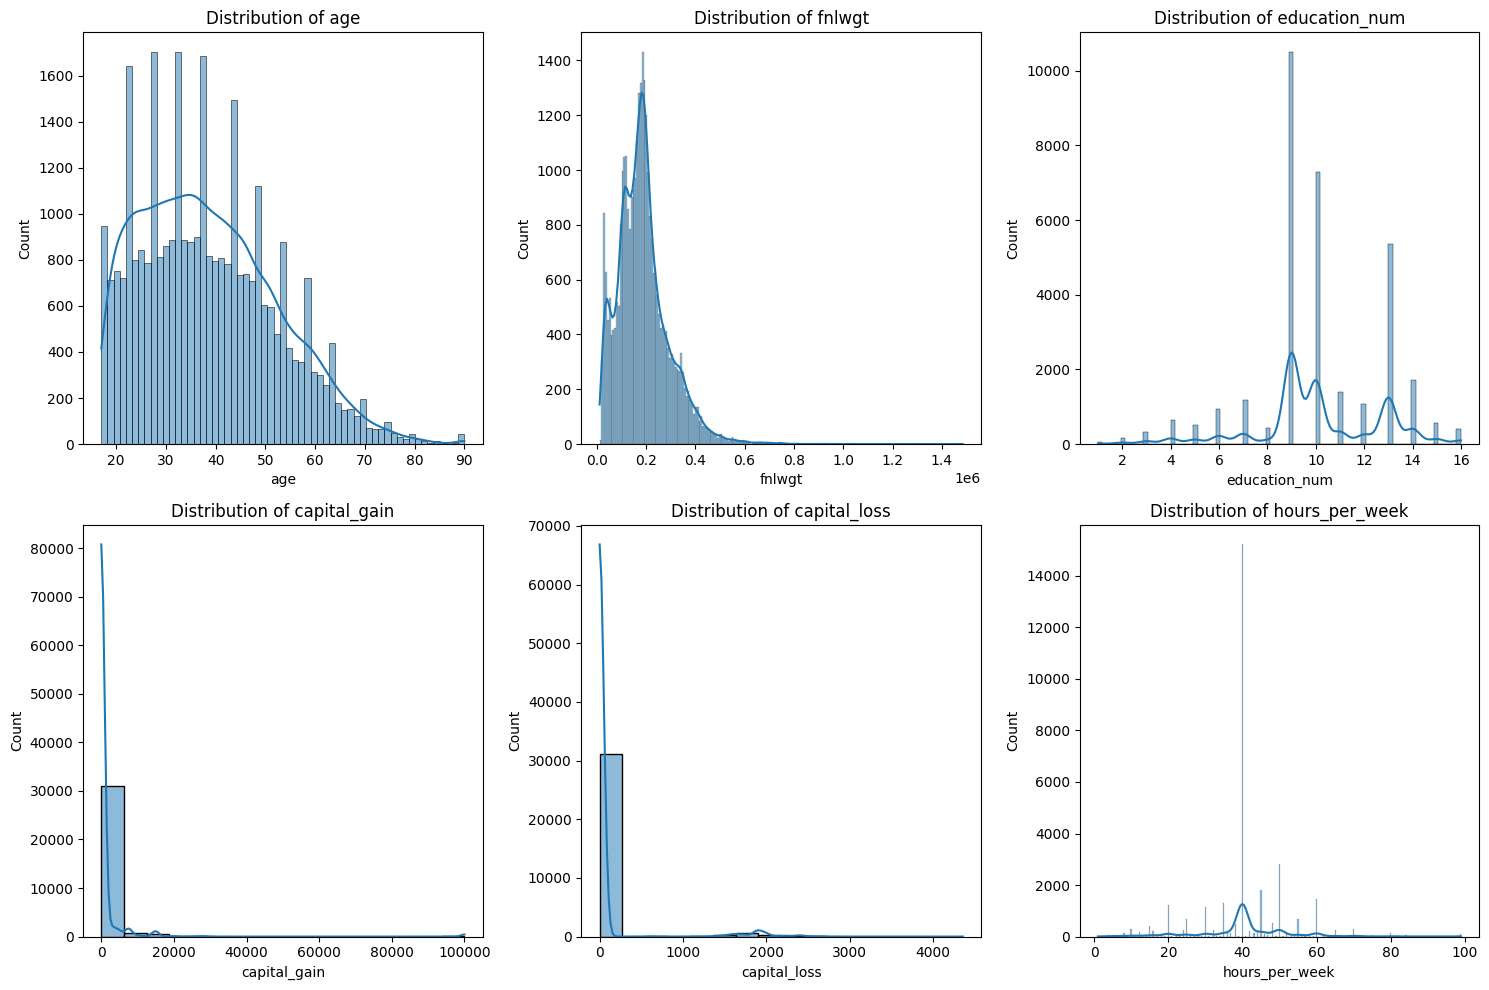

From the histograms, 'capital_gain' and 'capital_loss' appear to be highly skewed.
We will apply a log transformation to 'capital_gain' and 'capital_loss' to reduce their skewness.

Distributions after log transformation:


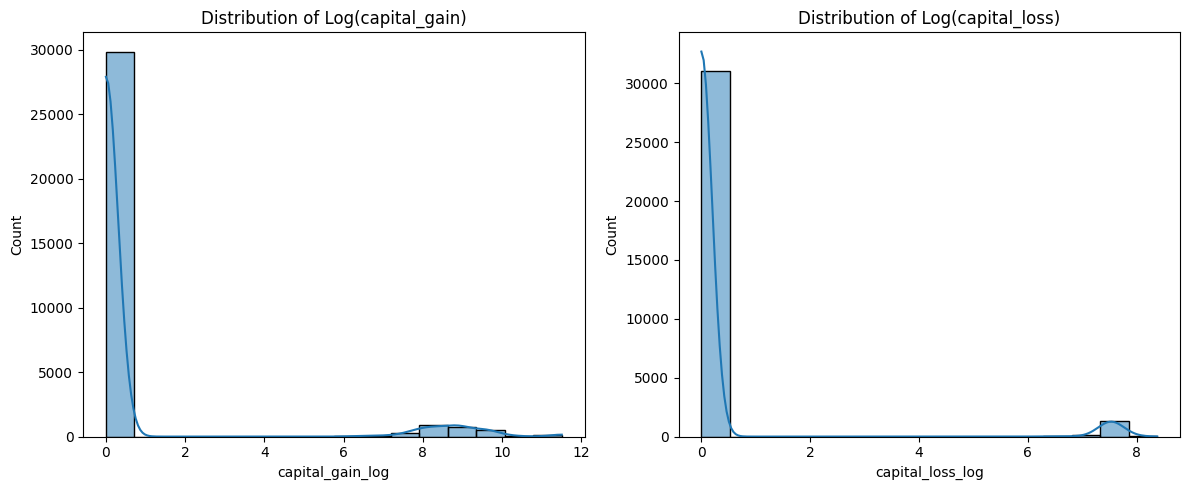

Rationale for log transformation: Log transformation helps in reducing the skewness of heavily skewed distributions. This can lead to a more normal-like distribution, which can be beneficial for many machine learning models that assume normally distributed features. `np.log1p` is used to handle zero values, as log(0) is undefined.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_original = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_original):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("From the histograms, 'capital_gain' and 'capital_loss' appear to be highly skewed.")
print("We will apply a log transformation to 'capital_gain' and 'capital_loss' to reduce their skewness.")

# Apply log transformation to skewed features
df_feature_engineered = df_encoded.copy() # Start from the encoded DataFrame

# Add a small constant to handle zero values before log transformation
df_feature_engineered['capital_gain_log'] = np.log1p(df_feature_engineered['capital_gain'])
df_feature_engineered['capital_loss_log'] = np.log1p(df_feature_engineered['capital_loss'])

print("\nDistributions after log transformation:")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_feature_engineered['capital_gain_log'], kde=True)
plt.title('Distribution of Log(capital_gain)')

plt.subplot(1, 2, 2)
sns.histplot(df_feature_engineered['capital_loss_log'], kde=True)
plt.title('Distribution of Log(capital_loss)')
plt.tight_layout()
plt.show()

print("Rationale for log transformation: Log transformation helps in reducing the skewness of heavily skewed distributions. This can lead to a more normal-like distribution, which can be beneficial for many machine learning models that assume normally distributed features. `np.log1p` is used to handle zero values, as log(0) is undefined.")

### Create New Features

In [13]:
# 1. Feature: Total Capital Transaction
# This feature combines capital gain and capital loss, representing the overall financial activity related to investments.
# It might provide a more holistic view of an individual's investment behavior than gain and loss separately.
df_feature_engineered['total_capital_transactions'] = df_feature_engineered['capital_gain'] + df_feature_engineered['capital_loss']
print("Created 'total_capital_transactions' feature.")

# 2. Feature: Hours Worked per Week per Age (simplified productivity/effort ratio)
# This feature could indicate how many hours a person works relative to their age.
# Younger individuals might work fewer hours due to education, while older individuals might work fewer due to retirement.
# Higher values could indicate higher productivity or work dedication for their age group.
df_feature_engineered['hours_per_week_per_age'] = df_feature_engineered['hours_per_week'] / (df_feature_engineered['age'] + 1) # Added 1 to age to avoid division by zero if age could be 0, though minimum age is 17.
print("Created 'hours_per_week_per_age' feature.")

print("\nFirst 5 rows with new features:")
display(df_feature_engineered[['capital_gain', 'capital_loss', 'capital_gain_log', 'capital_loss_log', 'total_capital_transactions', 'hours_per_week', 'age', 'hours_per_week_per_age']].head())

print("\nRationale for new features:")
print("1. **Total Capital Transaction (`total_capital_transactions`):** This feature aggregates the capital gain and loss, which individually might not fully capture the financial investment activity. A person might have both gains and losses. This combined feature could offer a more comprehensive understanding of their investment engagement, potentially correlating with income levels. For instance, individuals with significant capital transactions (whether gain or loss) might be more involved in financial markets, which could be a proxy for higher income or financial savviness.")
print("2. **Hours Worked per Week per Age (`hours_per_week_per_age`):** This ratio attempts to normalize the hours worked by age. It could highlight individuals who are working disproportionately high or low hours for their age group. For example, a young person working very long hours might be ambitious and thus have higher income potential, while an older person working fewer hours might be semi-retired or working a high-paying, less hour-intensive job. This feature aims to capture a form of 'effort' or 'intensity' relative to life stage.")

print("\nDataFrame shape after feature engineering:", df_feature_engineered.shape)
print("Final check on dataframe info after feature engineering:")
df_feature_engineered.info()

Created 'total_capital_transactions' feature.
Created 'hours_per_week_per_age' feature.

First 5 rows with new features:


,capital_gain,capital_loss,capital_gain_log,capital_loss_log,total_capital_transactions,hours_per_week,age,hours_per_week_per_age
0,2174,0,7.684784,0.0,2174,40,39,1.000000
1,0,0,0.000000,0.0,0,13,50,0.254902
2,0,0,0.000000,0.0,0,40,38,1.025641
3,0,0,0.000000,0.0,0,40,53,0.740741
4,0,0,0.000000,0.0,0,40,28,1.379310



Rationale for new features:
1. **Total Capital Transaction (`total_capital_transactions`):** This feature aggregates the capital gain and loss, which individually might not fully capture the financial investment activity. A person might have both gains and losses. This combined feature could offer a more comprehensive understanding of their investment engagement, potentially correlating with income levels. For instance, individuals with significant capital transactions (whether gain or loss) might be more involved in financial markets, which could be a proxy for higher income or financial savviness.
2. **Hours Worked per Week per Age (`hours_per_week_per_age`):** This ratio attempts to normalize the hours worked by age. It could highlight individuals who are working disproportionately high or low hours for their age group. For example, a young person working very long hours might be ambitious and thus have higher income potential, while an older person working fewer hours might be sem